# Lab 1 – Basics of Programming with Python

## Steps 1-4: Environment setup
Install libraries (run once if missing): `pip install numpy opencv-python scikit-image pillow matplotlib scipy`

## Task 2: Loading and visualizing images

### Using OpenCV

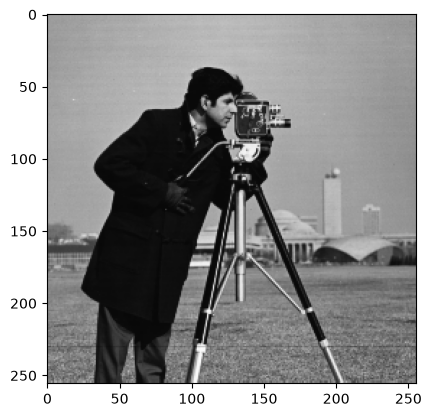

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../images/cameraman.tiff')   # loads image data into a NumPy array
plt.imshow(img)
plt.show()

### Using PIL

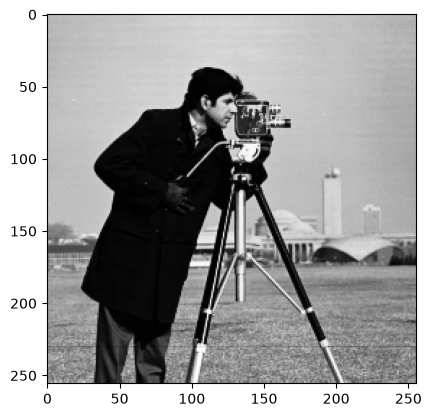

In [2]:
from PIL import Image
import matplotlib.cm as cm

img2 = Image.open('../images/cameraman.tiff')   # loads image into a PIL Image object
plt.imshow(img2, cmap=cm.Greys_r)
plt.show()

## Task 3: Image storing

In [3]:
cv2.imwrite('new_image.jpg', img)   # OpenCV
img2.save('new_image2.jpg')         # PIL

## Task 4: Display image as an array

In [4]:
print(img.shape)   # img loaded with OpenCV is a NumPy array
print(img)

(256, 256, 3)
[[[156 156 156]
  [159 159 159]
  [158 158 158]
  ...
  [151 151 151]
  [152 152 152]
  [152 152 152]]

 [[160 160 160]
  [154 154 154]
  [157 157 157]
  ...
  [154 154 154]
  [155 155 155]
  [153 153 153]]

 [[156 156 156]
  [159 159 159]
  [158 158 158]
  ...
  [151 151 151]
  [152 152 152]
  [152 152 152]]

 ...

 [[114 114 114]
  [132 132 132]
  [123 123 123]
  ...
  [135 135 135]
  [137 137 137]
  [114 114 114]]

 [[121 121 121]
  [126 126 126]
  [130 130 130]
  ...
  [133 133 133]
  [130 130 130]
  [113 113 113]]

 [[121 121 121]
  [126 126 126]
  [130 130 130]
  ...
  [133 133 133]
  [130 130 130]
  [113 113 113]]]


In [5]:
img_array = np.array(img2)
print(img_array.shape)
print(img_array)

(256, 256)
[[156 159 158 ... 151 152 152]
 [160 154 157 ... 154 155 153]
 [156 159 158 ... 151 152 152]
 ...
 [114 132 123 ... 135 137 114]
 [121 126 130 ... 133 130 113]
 [121 126 130 ... 133 130 113]]


# Assessment: Array operations with NumPy

In [6]:
gray = img_array.astype(np.float64)
print('dtype:', img_array.dtype, '| size:', img_array.size)
print('min: %d  max: %d  mean: %.2f  std: %.2f' % (gray.min(), gray.max(), gray.mean(), gray.std()))

dtype: uint8 | size: 65536
min: 7  max: 253  mean: 118.72  std: 62.34


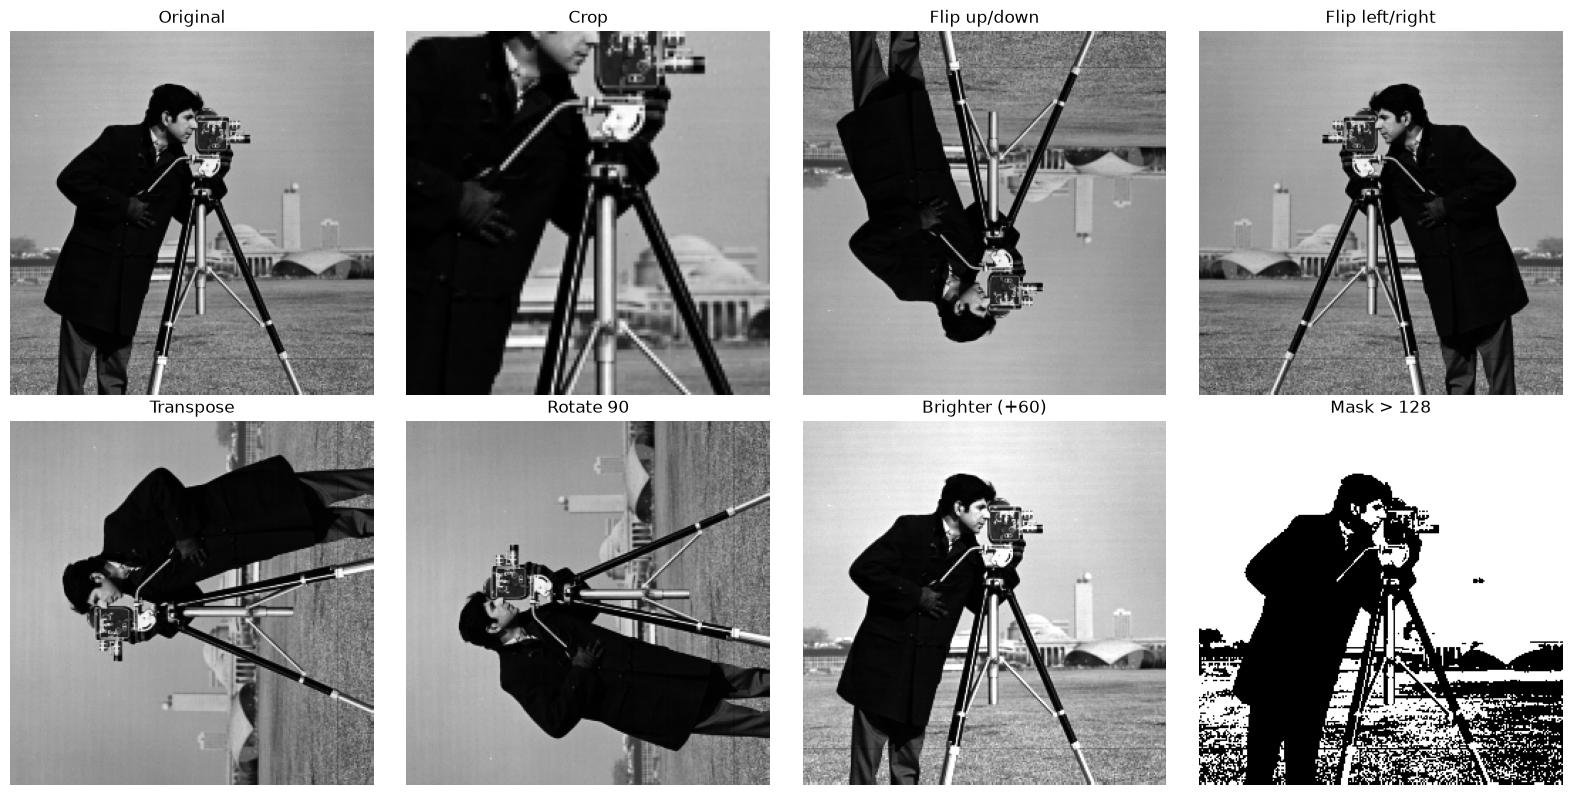

In [7]:
crop = img_array[64:192, 64:192]        # slicing
flip_ud = np.flipud(img_array)          # vertical flip
flip_lr = np.fliplr(img_array)          # horizontal flip
transposed = img_array.T                # transpose
rot90 = np.rot90(img_array)             # rotate 90 degrees
bright = np.clip(gray + 60, 0, 255).astype(np.uint8)   # arithmetic on arrays
mask = (img_array > 128)                # boolean masking

imgs = [img_array, crop, flip_ud, flip_lr, transposed, rot90, bright, mask]
titles = ['Original', 'Crop', 'Flip up/down', 'Flip left/right', 'Transpose', 'Rotate 90', 'Brighter (+60)', 'Mask > 128']
plt.figure(figsize=(16, 8))
for i, (im, t) in enumerate(zip(imgs, titles), 1):
    plt.subplot(2, 4, i); plt.imshow(im, cmap='gray'); plt.title(t); plt.axis('off')
plt.tight_layout(); plt.show()

In [8]:
print('Pixels above 128:', mask.sum())
print('Row means (first 5):', img_array.mean(axis=1)[:5].round(2))
print('Column means (first 5):', img_array.mean(axis=0)[:5].round(2))

Pixels above 128: 38668
Row means (first 5): [170.77 171.11 170.77 171.11 170.63]
Column means (first 5): [142.05 143.25 144.24 144.37 144.63]
